# Czym NAPRAWDĘ jest DFT? Struktura transformaty, nie tylko jej użycie

Poprzednie notatniki (ILUSTR1-3) pokazywały DFT **od strony użytkownika**: co się psuje, kiedy próbkujemy za rzadko (aliasing), kiedy okno obserwacji jest za krótkie (rozdzielczość), kiedy sygnał nie mieści się w oknie całkowitą liczbę razy (wyciek widma), i dlaczego FFT liczy to samo szybciej.

Tutaj otwieramy "czarną skrzynkę" samej transformaty. Cztery pytania, na które odpowiadamy:

1. **DFT jako mnożenie przez macierz** — co dokładnie się dzieje, gdy liczymy `fft(x)`?
2. **Unitarność DFT** — dlaczego DFT nie "gubi" ani nie "dodaje" informacji, tylko ją obraca?
3. **Rzeczywista DFT a zespolona DFT** — skąd bierze się symetria widma i dlaczego `rfft` zwraca połowę wyników?
4. **Założenie okresowości** — dlaczego DFT zawsze zakłada, że analizowany fragment sygnału powtarza się w nieskończoność?

Odpowiedzi na te pytania nie są potrzebne, żeby *używać* DFT — ale są potrzebne, żeby zrozumieć, *dlaczego* zjawiska z poprzednich notatników (wyciek, symetria widma, skalowanie amplitudy) w ogóle występują.

In [1]:
# Przykładowy sygnał rzeczywisty: N=8 próbek, mieszanka dwóch częstotliwości
# Celowo mała liczba próbek (N=8), żeby dało się jeszcze "z bliska" zobaczyć
# każdy pojedynczy element macierzy/wektora -- przy N=1000 te same wzory
# obowiązują identycznie, tylko nic nie widać na wykresie.
import numpy as np
import matplotlib.pyplot as plt

N = 8
n = np.arange(N)
x = np.cos(2*np.pi*1*n/N) + 0.5*np.sin(2*np.pi*2*n/N + 0.3)

print("Sygnal x[n] (N=%d probek):" % N)
for i in range(N):
    print(f"  x[{i}] = {x[i]:.4f}")


Sygnal x[n] (N=8 probek):
  x[0] = 1.1478
  x[1] = 1.1848
  x[2] = -0.1478
  x[3] = -1.1848
  x[4] = -0.8522
  x[5] = -0.2294
  x[6] = -0.1478
  x[7] = 0.2294


## 1. DFT jako mnożenie przez macierz

Definicja DFT to nic innego niż suma:

$$X[k] = \sum_{n=0}^{N-1} x[n]\, e^{-i 2\pi k n / N}, \qquad k=0,1,\dots,N-1$$

Dla ustalonego $N$ liczby $e^{-i2\pi kn/N}$ nie zależą od konkretnego sygnału $x$ — są stałe. Możemy więc ustawić je w macierz $\mathbf{F}$ o wymiarach $N\times N$, gdzie $\mathbf{F}[k,n] = e^{-i2\pi kn/N}$, i zapisać całą transformatę jako **jedno mnożenie macierzowe**:

$$\mathbf{X} = \mathbf{F}\,\mathbf{x}$$

Każdy wiersz $k$ macierzy $\mathbf{F}$ to próbki (zespolonej) sinusoidy o częstotliwości $k$ — tzw. **baza DFT**. Policzenie $X[k]$ to policzenie iloczynu skalarnego sygnału z $k$-tą sinusoidą bazową.

Maks. roznica |F@x - fft(x)|: 2.230403245675806e-15


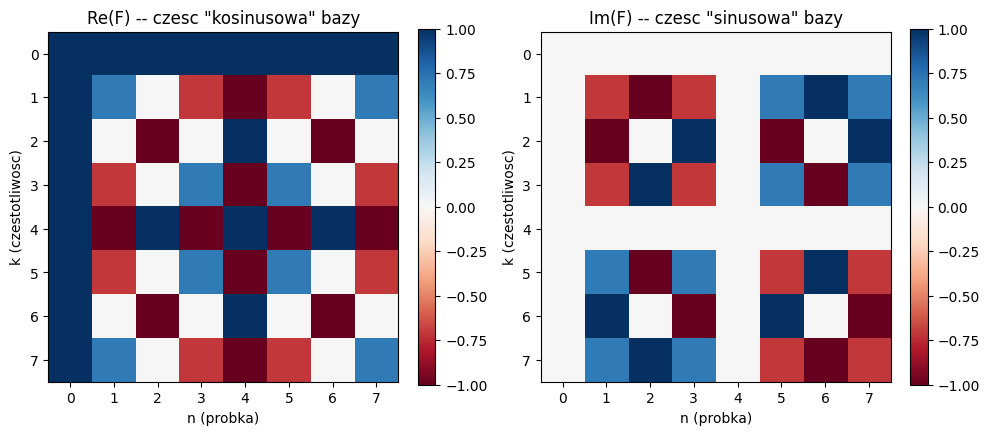

In [2]:
# Budujemy macierz DFT wprost z definicji: F[k,n] = exp(-2j*pi*k*n/N)
k_idx = np.arange(N).reshape(-1, 1)   # kolumna
n_idx = np.arange(N).reshape(1, -1)   # wiersz
F = np.exp(-2j*np.pi*k_idx*n_idx/N)

# Sprawdzenie: F @ x powinno dac dokladnie to samo co np.fft.fft(x)
X_macierzowo = F @ x
X_fft = np.fft.fft(x)
print("Maks. roznica |F@x - fft(x)|:", np.max(np.abs(X_macierzowo - X_fft)))

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
im0 = axes[0].imshow(F.real, cmap='RdBu', vmin=-1, vmax=1)
axes[0].set_title('Re(F) -- czesc "kosinusowa" bazy')
axes[0].set_xlabel('n (probka)')
axes[0].set_ylabel('k (czestotliwosc)')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(F.imag, cmap='RdBu', vmin=-1, vmax=1)
axes[1].set_title('Im(F) -- czesc "sinusowa" bazy')
axes[1].set_xlabel('n (probka)')
axes[1].set_ylabel('k (czestotliwosc)')
plt.colorbar(im1, ax=axes[1], fraction=0.046)
plt.tight_layout()
plt.show()


Każdy **wiersz** macierzy to jedna zespolona sinusoida bazowa — wiersz $k=0$ jest stały (częstotliwość zerowa, składowa DC), wiersz $k=1$ oscyluje raz na całe okno, wiersz $k=2$ — dwa razy, itd. `fft(x)` nie robi nic więcej niż to mnożenie macierzowe — po prostu **znacznie szybciej** niż $O(N^2)$ (zobacz ILUSTR3).

### Skąd biorą się liczby zespolone? Widok "wektorowy" (fazory)

Dla ustalonego $k$, $X[k]$ to suma $N$ liczb zespolonych $x[n]\cdot e^{-i2\pi kn/N}$ — każda to **rzeczywista** liczba $x[n]$ obrócona o kąt zależny od $n$ i $k$. Same próbki sygnału są rzeczywiste (leżą na osi liczb rzeczywistych), ale mnożenie przez $e^{-i2\pi kn/N}$ "wypycha" je w płaszczyznę zespoloną, obracając każdą pod innym kątem. Zsumowanie tych obróconych wektorów (fazorów) daje jedną liczbę zespoloną $X[k]$.

Poniżej porównanie dla dwóch wartości $k$: jednej, która **pasuje** do częstotliwości obecnej w sygnale (wektory ustawiają się w miarę zgodnie, długa suma), i jednej, która **nie pasuje** (wektory wskazują w różne strony, prawie się znoszą).

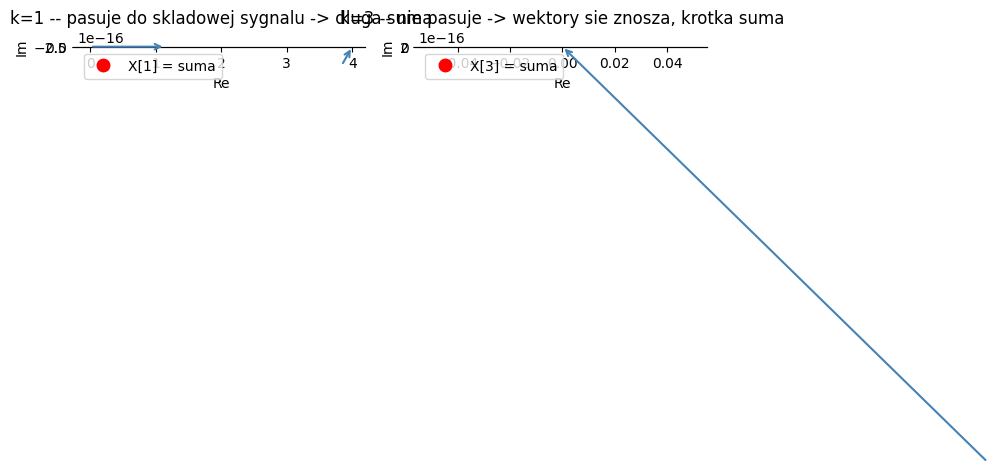

In [3]:
def rysuj_fazory(x, k, N, ax):
    # Wektory skladowe sumy: x[n] * exp(-2j*pi*k*n/N) dla n=0..N-1,
    # rysowane "koniec do poczatku" (suma czesciowa), zeby widac bylo,
    # jak sklada sie ostateczny wynik X[k].
    skladniki = x * np.exp(-2j*np.pi*k*np.arange(N)/N)
    start = 0+0j
    for term in skladniki:
        ax.annotate('', xy=(start.real+term.real, start.imag+term.imag),
                     xytext=(start.real, start.imag),
                     arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.5))
        start += term
    suma = np.sum(skladniki)
    ax.plot(suma.real, suma.imag, 'ro', markersize=9, label=f'X[{k}] = suma')
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_xlabel('Re')
    ax.set_ylabel('Im')
    ax.legend()
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
rysuj_fazory(x, k=1, N=N, ax=axes[0])
axes[0].set_title('k=1 -- pasuje do skladowej sygnalu -> dluga suma')
rysuj_fazory(x, k=3, N=N, ax=axes[1])
axes[1].set_title('k=3 -- nie pasuje -> wektory sie znosza, krotka suma')
plt.tight_layout()
plt.show()


## 2. Unitarność DFT: transformata nic nie gubi, tylko obraca

Macierz $\mathbf{F}$ ma szczególną własność: jej wiersze są **wzajemnie ortogonalne** — iloczyn skalarny dwóch różnych wierszy wynosi zero, a wiersza z samym sobą — $N$:

$$\sum_{n=0}^{N-1} e^{-i2\pi kn/N}\,\overline{e^{-i2\pi ln/N}} = \begin{cases} N & k=l \\ 0 & k\neq l\end{cases}$$

To dokładny wynik (sumowanie szeregu geometrycznego), nie przybliżenie. Skoro tak, to macierz $\mathbf{U}=\mathbf{F}/\sqrt{N}$ spełnia $\mathbf{U}^H\mathbf{U}=\mathbf{I}$ — jest **unitarna** (zespolony odpowiednik macierzy ortogonalnej/obrotu). Konsekwencje:

- transformata jest **odwracalna bez utraty informacji** wzorem $\mathbf{x}=\mathbf{F}^{-1}\mathbf{X}=\frac{1}{N}\mathbf{F}^H\mathbf{X}$ (stąd $1/N$ we wzorze na IDFT),
- **energia sygnału jest zachowana** (twierdzenie Parsevala): $\sum_n |x[n]|^2 = \frac{1}{N}\sum_k |X[k]|^2$ — DFT tylko "obraca" wektor sygnału do innego układu współrzędnych (bazy częstotliwościowej), nie zmieniając jego długości (energii).

In [4]:
# Sprawdzenie ortogonalnosci wierszy F: F @ F^H powinno dac N * I (macierz diagonalna)
gram = F @ F.conj().T
print("Maks. |element pozadiagonalny| macierzy F @ F^H:",
      np.max(np.abs(gram - np.diag(np.diag(gram)))))
print("Elementy diagonalne (powinny byc = N =", N, "):", np.real(np.diag(gram)))

# Sprawdzenie unitarnosci U = F/sqrt(N): U^H @ U ~ I
U = F / np.sqrt(N)
roznica_od_I = U.conj().T @ U - np.eye(N)
print("\nMaks. odchylenie U^H@U od macierzy jednostkowej:", np.max(np.abs(roznica_od_I)))

# Sprawdzenie twierdzenia Parsevala na naszym sygnale x
energia_czas = np.sum(np.abs(x)**2)
energia_widmo = np.sum(np.abs(X_fft)**2) / N
print(f"\nEnergia w dziedzinie czasu:    {energia_czas:.6f}")
print(f"Energia w dziedzinie czestotl: {energia_widmo:.6f}  (powinny byc rowne)")


Maks. |element pozadiagonalny| macierzy F @ F^H: 5.846849630181279e-15
Elementy diagonalne (powinny byc = N = 8 ): [8. 8. 8. 8. 8. 8. 8. 8.]

Maks. odchylenie U^H@U od macierzy jednostkowej: 7.062098392711005e-16

Energia w dziedzinie czasu:    5.000000
Energia w dziedzinie czestotl: 5.000000  (powinny byc rowne)


## 3. Rzeczywista DFT a zespolona DFT

Nasz sygnał $x[n]$ jest **rzeczywisty**, ale $X[k]$ jest zespolone. To pozornie podwaja liczbę informacji (2 liczby rzeczywiste na $N$ zamiast $N$) — ale DFT sygnału rzeczywistego ma wbudowaną **symetrię sprzężoną** (ang. *conjugate symmetry*):

$$X[N-k] = \overline{X[k]}$$

Innymi słowy: $\mathrm{Re}(X[k])$ jest **parzyste** względem $k=N/2$, a $\mathrm{Im}(X[k])$ jest **nieparzyste**. Połowa współczynników zespolonych ($k=0,\dots,N/2$) niesie więc **całą** informację — druga połowa to tylko sprzężenia pierwszej. To właśnie dlatego `np.fft.rfft`/`scipy` dla sygnałów rzeczywistych zwraca tylko $\lfloor N/2\rfloor+1$ liczb zamiast $N$: **rzeczywista DFT (RDFT) to nie inny algorytm, tylko ta sama zespolona DFT z odrzuconą, redundantną połową.**

 k |        X[k]        |       X[N-k]        | X[N-k]==conj(X[k])?
 1 |     4.0000-0.0000j |     4.0000+0.0000j | True
 2 |     0.5910-1.9107j |     0.5910+1.9107j | True
 3 |    -0.0000+0.0000j |    -0.0000-0.0000j | True
 4 |     0.0000+0.0000j |     0.0000+0.0000j | True
 5 |    -0.0000-0.0000j |    -0.0000+0.0000j | True
 6 |     0.5910+1.9107j |     0.5910-1.9107j | True
 7 |     4.0000+0.0000j |     4.0000-0.0000j | True


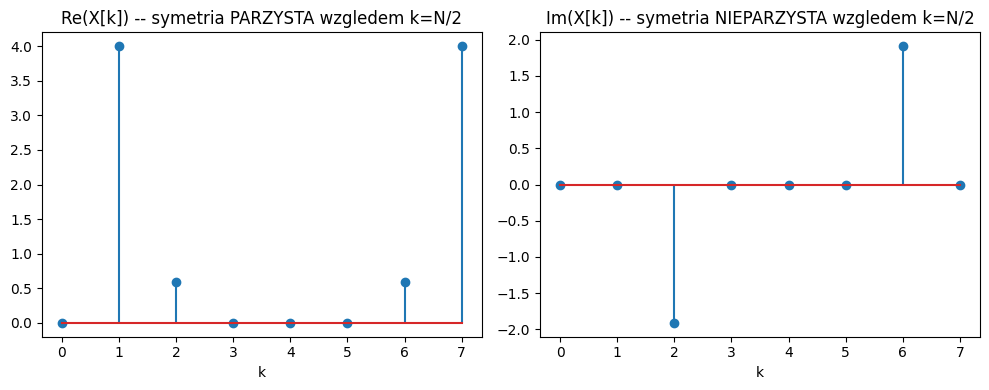

In [5]:
print(" k |        X[k]        |       X[N-k]        | X[N-k]==conj(X[k])?")
for kk in range(1, N):
    lhs = X_fft[(N - kk) % N]
    rhs = np.conj(X_fft[kk])
    zgodnosc = np.isclose(lhs, rhs)
    print(f"{kk:2d} | {X_fft[kk]:18.4f} | {lhs:18.4f} | {zgodnosc}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].stem(range(N), X_fft.real)
axes[0].set_title('Re(X[k]) -- symetria PARZYSTA wzgledem k=N/2')
axes[0].set_xlabel('k')
axes[1].stem(range(N), X_fft.imag)
axes[1].set_title('Im(X[k]) -- symetria NIEPARZYSTA wzgledem k=N/2')
axes[1].set_xlabel('k')
plt.tight_layout()
plt.show()


In [6]:
# Odtworzenie sygnalu z "polowy" widma w postaci amplituda/faza (rzeczywista DFT)
# -- pokazuje, ze polowa zespolonych wspolczynnikow niesie CALA informacje.
# UWAGA: ten fragment zaklada N PARZYSTE (tak jak nasz przyklad) -- tylko
# wtedy istnieje pojedynczy, rzeczywisty prazek Nyquista X[N/2]. Dla N
# nieparzystego nie ma osobnej skladowej Nyquista i wzor trzeba zmodyfikowac.
a0 = X_fft[0].real / N                 # skladowa stala
a_nyquist = X_fft[N//2].real / N       # skladowa Nyquista (N parzyste)

def zrekonstruuj(n):
    wynik = a0 + a_nyquist * (-1)**n
    for kk in range(1, N//2):
        amplituda = 2*np.abs(X_fft[kk]) / N
        faza = np.angle(X_fft[kk])
        wynik += amplituda * np.cos(2*np.pi*kk*n/N + faza)
    return wynik

x_odtworzony = np.array([zrekonstruuj(nn) for nn in range(N)])
print("x oryginalne:   ", np.round(x, 4))
print("x odtworzone:   ", np.round(x_odtworzony, 4))
print("Maks. roznica:  ", np.max(np.abs(x - x_odtworzony)))


x oryginalne:    [ 1.1478  1.1848 -0.1478 -1.1848 -0.8522 -0.2294 -0.1478  0.2294]
x odtworzone:    [ 1.1478  1.1848 -0.1478 -1.1848 -0.8522 -0.2294 -0.1478  0.2294]
Maks. roznica:   6.661338147750939e-16


## 4. Założenie okresowości: DFT nie widzi "urwanego sygnału"

Wzór na odwrotną DFT (IDFT), $x[n]=\frac{1}{N}\sum_k X[k]e^{i2\pi kn/N}$, formalnie ma sens dla **dowolnego** $n$, nie tylko $n=0,\dots,N-1$ — a ponieważ $e^{i2\pi k(n+N)/N}=e^{i2\pi kn/N}$ (funkcja bazowa ma okres $N$), to podstawienie $n+N$ daje **dokładnie ten sam wynik** co $n$. DFT z definicji traktuje więc nasze $N$ próbek jako **jeden okres nieskończenie powtarzanego sygnału** — nie jako fragment czegoś dłuższego, co się urywa na brzegach okna.

To założenie ma konkretną, praktyczną konsekwencję: **mnożenie w dziedzinie częstotliwości odpowiada splotowi *kołowemu* (cyklicznemu) w dziedzinie czasu, nie zwykłemu splotowi liniowemu** — bo splot "zawija się" na granicy okna, tak jak zawija się sam sygnał.

In [7]:
# Wzor IDFT policzony dla n POZA zakresem [0, N-1] -- powinien powtorzyc x
print("IDFT policzone dla n=N..N+3 (poza oryginalnym oknem):")
for nn in range(N, N+4):
    wartosc = np.sum(X_fft * np.exp(2j*np.pi*np.arange(N)*nn/N)) / N
    print(f"  n={nn}: IDFT={wartosc.real:.4f}   (x[{nn % N}]={x[nn % N]:.4f})")


IDFT policzone dla n=N..N+3 (poza oryginalnym oknem):
  n=8: IDFT=1.1478   (x[0]=1.1478)
  n=9: IDFT=1.1848   (x[1]=1.1848)
  n=10: IDFT=-0.1478   (x[2]=-0.1478)
  n=11: IDFT=-1.1848   (x[3]=-1.1848)


In [8]:
# Splot LINIOWY a splot KOLOWY na prostym przykladzie -- pokazuje praktyczny
# skutek zalozenia okresowosci: mnozenie widm w DFT to splot KOLOWY.
a = np.array([1, 2, 3, 4], dtype=float)
b = np.array([1, 0, 0, 1], dtype=float)

splot_liniowy = np.convolve(a, b)  # dlugosc len(a)+len(b)-1 = 7

def splot_kolowy(a, b):
    N = len(a)
    wynik = np.zeros(N)
    for nn in range(N):
        for kk in range(N):
            wynik[nn] += a[kk] * b[(nn - kk) % N]  # indeks "zawija sie" modulo N
    return wynik

splot_kol = splot_kolowy(a, b)

# Ten sam wynik splotu kolowego da mnozenie w dziedzinie DFT + IDFT:
Xa, Xb = np.fft.fft(a), np.fft.fft(b)
splot_przez_dft = np.fft.ifft(Xa * Xb).real

print("Splot liniowy (np.convolve):         ", splot_liniowy)
print("Splot kolowy (definicja wprost):     ", splot_kol)
print("Mnozenie widm DFT -> IDFT:            ", np.round(splot_przez_dft, 6))
print("\nSplot kolowy != poczatek splotu liniowego -- to bezposredni skutek")
print("zalozenia okresowosci sygnalu przez DFT (por. wyciek widma w ILUSTR2:")
print("ten sam mechanizm 'zawijania' na brzegu okna).")


Splot liniowy (np.convolve):          [1. 2. 3. 5. 2. 3. 4.]
Splot kolowy (definicja wprost):      [3. 5. 7. 5.]
Mnozenie widm DFT -> IDFT:             [3. 5. 7. 5.]

Splot kolowy != poczatek splotu liniowego -- to bezposredni skutek
zalozenia okresowosci sygnalu przez DFT (por. wyciek widma w ILUSTR2:
ten sam mechanizm 'zawijania' na brzegu okna).


## Najważniejsze wnioski

- **DFT to mnożenie przez ustaloną macierz** $\mathbf{F}$, której wiersze to próbkowane zespolone sinusoidy (baza DFT) — `fft()` liczy dokładnie ten wynik, tylko szybciej.
- Liczby zespolone w wyniku biorą się stąd, że każda rzeczywista próbka $x[n]$ jest mnożona przez $e^{-i2\pi kn/N}$, czyli **obracana** w płaszczyźnie zespolonej o kąt zależny od $n$ i $k$, zanim zostanie zsumowana.
- Baza DFT jest **ortogonalna**, więc znormalizowana macierz DFT jest **unitarna** — transformata jest w pełni odwracalna i zachowuje energię sygnału (twierdzenie Parsevala).
- **Rzeczywista DFT nie jest osobnym algorytmem** — to ta sama zespolona DFT dla sygnału rzeczywistego, wykorzystująca symetrię sprzężoną $X[N-k]=\overline{X[k]}$, żeby nie liczyć/nie przechowywać redundantnej połowy wyniku.
- DFT **zawsze zakłada, że okno próbek to jeden okres sygnału nieskończenie powtarzanego** — stąd splot w dziedzinie DFT jest splotem *kołowym*, i stąd (ILUSTR2) wyciek widma, gdy założenie okresowości nie pasuje do rzeczywistego sygnału.

## Ćwiczenia

1. Zmień `N` na 6 (sygnał `x` zdefiniuj od nowa dla tego `N`) i sprawdź, czy ortogonalność wierszy `F` i twierdzenie Parsevala nadal się zgadzają.
2. Narysuj fazory (jak w sekcji 1) dla `k=2` i `k=6` — zauważ, że to para $k$, $N-k$ z symetrii sprzężonej. Czym różnią się rysunki?
3. Podmień sygnał `x` na **zespolony** (np. dodaj `+ 1j*np.sin(...)`) i sprawdź, czy symetria $X[N-k]=\overline{X[k]}$ nadal zachodzi. Czy zgadza się to z tym, że symetria sprzężona wynika z założenia, że sygnał jest rzeczywisty?
4. Dopisz wersję `splot_kolowy`, która zamiast `(nn - kk) % N` używa zwykłego `nn - kk` bez zawijania (czyli de facto liczy coś bliższego splotowi liniowemu na skróconym zakresie) i porównaj wynik z obiema wersjami powyżej — upewnij się, które dokładnie indeksy się różnią.